In [13]:
import numpy as np
import matplotlib.pyplot as plt

import numpy as np
import os

downloads = os.path.join(os.path.expanduser("~"), "Downloads")

filename = os.path.join(downloads, "data_N1-197_step4_nmax300_w1.0_w01.0_g1.0.npz")

data = np.load(filename)

# extract arrays
N_arr = data["N"]
E_ergo = data["Eerg"]
E_var = data["variance"]
E_ratio = data["ratio"]
E_B = data["Eb"]

# derived quantities
F_ratio = np.sqrt(E_var) / E_ergo
FE_ratio = np.sqrt(E_var) / E_B

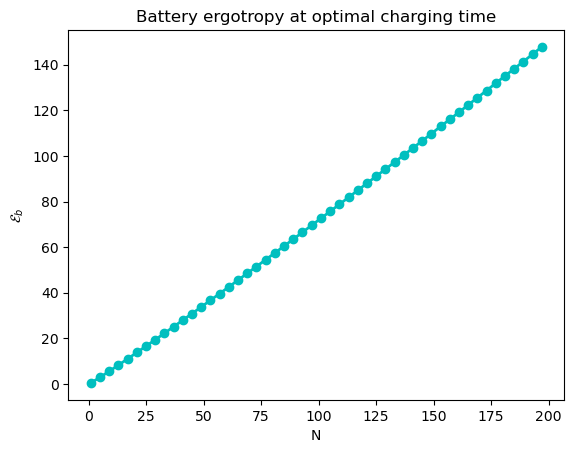

In [25]:
###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("OP1")
plt.show()

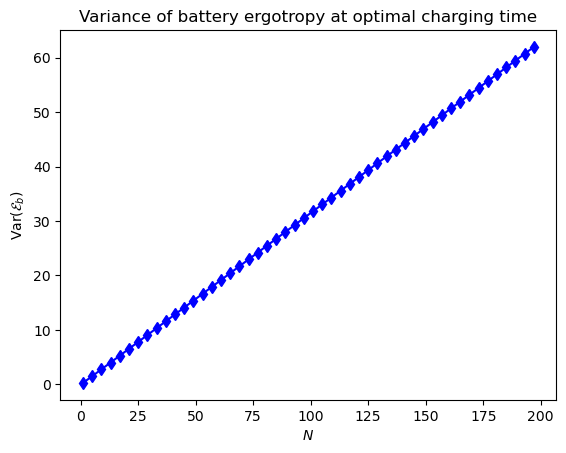

In [17]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
#plt.savefig("OP2")
plt.show()

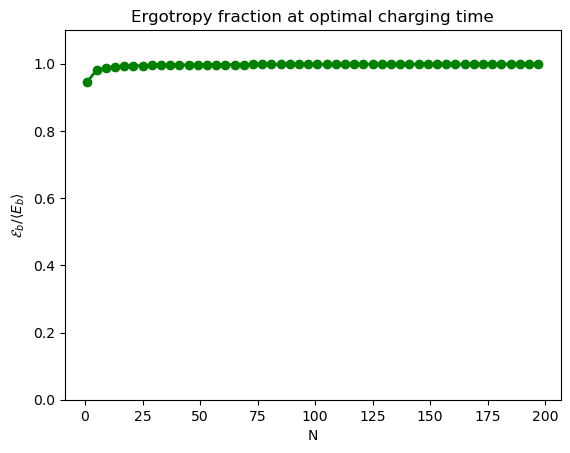

In [19]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
# plt.savefig("OP3")
plt.show()

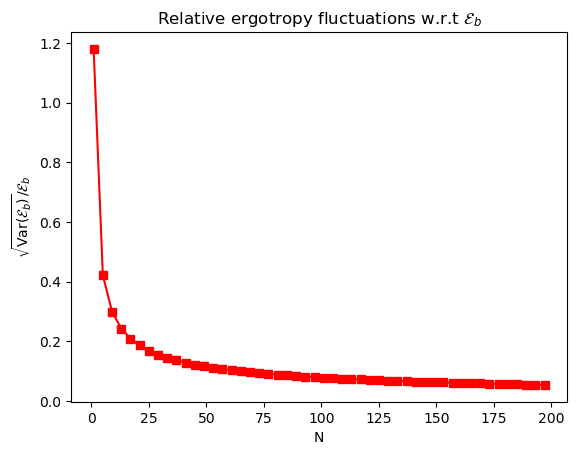

In [21]:
######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
# plt.savefig("OP4")
plt.show()

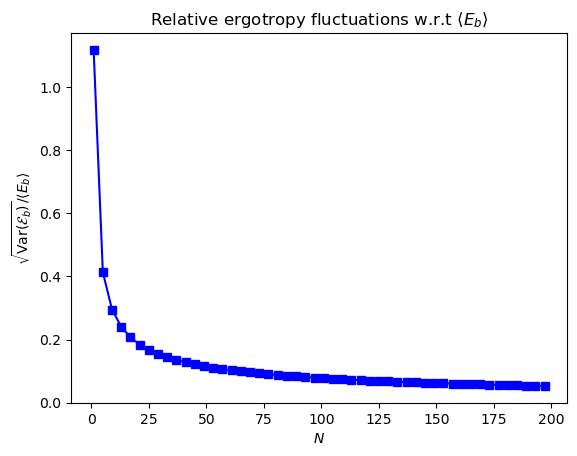

In [23]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
# plt.savefig("OP5")
plt.show()

Best fit parameters: A = 0.057075


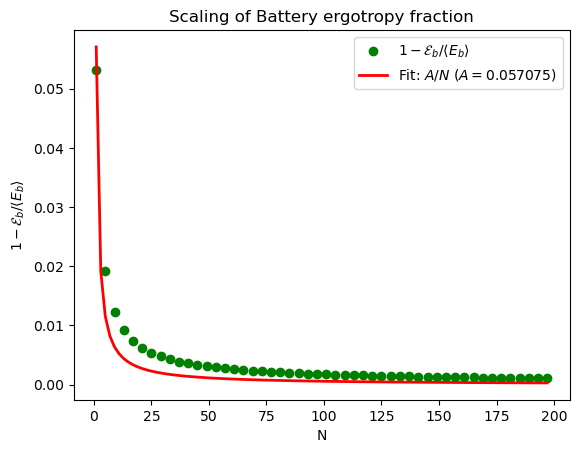

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# The fitting function
def asymptotic_fit(N, A):
    return (A / N)


y_data = 1 - np.array(E_ratio) 

# The curve fit

popt, pcov = curve_fit(asymptotic_fit, N_arr, y_data)
A_opt = popt[0]

print(f"Best fit parameters: A = {A_opt:.6f}")

# A smooth curve for the fit using the optimal parameters

N_smooth = np.linspace(min(N_arr), max(N_arr), 100)
y_fit = asymptotic_fit(N_smooth, A_opt)

# Plot the original data and the fitted curve

plt.plot(N_arr, y_data, 'o', color='g', markersize=6, label=r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.plot(N_smooth, y_fit, '-', color='r', linewidth=2, label=rf'Fit: $A/N$ ($A={A_opt:.6f}$)')

plt.xlabel("N")
plt.ylabel(r"$1 - \mathcal{E}_b / \langle E_b \rangle$")
plt.title("Scaling of Battery ergotropy fraction")
plt.legend()
# plt.savefig("OP6")
plt.show()

Best fit parameter: A = 0.166070


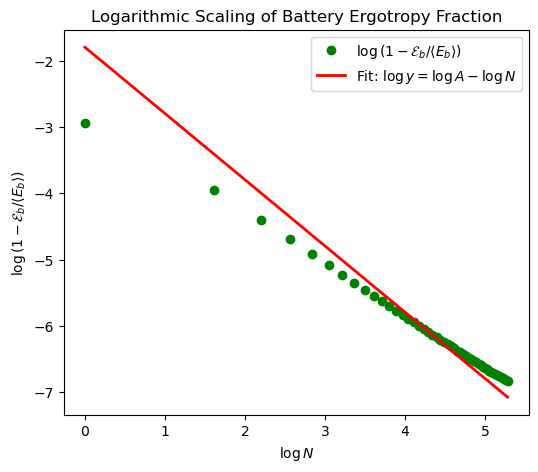

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Original data
y_data = 1 - np.array(E_ratio)

# Keep only positive values (required for logarithm)
mask = (N_arr > 0) & (y_data > 0)

N_fit = np.array(N_arr)[mask]
y_fit_data = y_data[mask]

# Take logarithms
log_N = np.log(N_fit)
log_y = np.log(y_fit_data)

# Linear fit in log-space:
# log(y) = log(A) - log(N)
def log_fit(log_N, logA):
    return logA - log_N

# Curve fitting in log space
popt, pcov = curve_fit(log_fit, log_N, log_y)

logA_opt = popt[0]
A_opt = np.exp(logA_opt)

print(f"Best fit parameter: A = {A_opt:.6f}")

# Smooth curve
N_smooth = np.linspace(min(N_fit), max(N_fit), 200)

# Corresponding fitted values
y_smooth = A_opt / N_smooth

# Plot
plt.figure(figsize=(6,5))

# Data points
plt.plot(log_N,log_y,'o',color='g',markersize=6,label=r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")

# Fitted straight line in log-space
plt.plot(np.log(N_smooth),np.log(y_smooth),'-',color='r',linewidth=2,label=rf'Fit: $\log y = \log A - \log N$')

plt.xlabel(r"$\log N$")
plt.ylabel(r"$\log\left(1 - \mathcal{E}_b / \langle E_b \rangle\right)$")
plt.title("Logarithmic Scaling of Battery Ergotropy Fraction")
plt.legend()
# plt.savefig("OP6_logfit")
plt.show()